# Výber pacienta pre semestrálny projekt

Podľa paperu sa úprava nastavenia prejavila len u pacientov s vyšším HbAc1
Z CGM datasetu vybrať pacienta s **vyššou priemernou glykémiou** (horšou kompenzáciou), kde je väčšia šanca zachytiť efekt intervencií (úprav parametrov pumpy).

**Kritériá výberu:**
- GMI > 7.5% (vyššia priemerná glykémia)
- Aspoň 50 000 záznamov (dostatočná dĺžka radu)
- TIR < 60% (pod cieľom, priestor na zlepšenie)

**Výstup:** Hodinový časový rad pre zvoleného pacienta → `data_patient_selected.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

C:\ProgramData\miniconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


In [2]:
import os
os.makedirs('outputs/data', exist_ok=True)
os.makedirs('outputs/images', exist_ok=True)

In [3]:
DATA_PATH = 'data/CGMValue.txt'
OUT_DATA = 'outputs/data/' # OUTPUT DATA PATH
OUT_IMG = 'outputs/images/' # OUTPUT IMAGES PATH

## 1. Načítanie dát

Dataset `CGMValue.txt` obsahuje CGM merania pre 112 pacientov z iDCL Trial (NCT03563313).  
Súbor je veľký (~223 MB), načítanie môže trvať niekoľko sekúnd.

In [4]:
# Načítanie celého datasetu
# Separator je '|', hlavička je v prvom riadku

df = pd.read_csv(DATA_PATH, sep='|', parse_dates=['DataDtTm'])
print(f'Rozmery: {df.shape}')
df.head()

Rozmery: (5677432, 6)


,PtID,RecID,DataDtTm,CGMValue,HighLowIndicator,DataDtTm_adjusted
0,22,1,2018-05-30 16:44:14,83,0,NaN
1,22,2,2018-05-30 16:59:15,117,0,NaN
2,22,3,2018-05-30 16:49:16,98,0,NaN
3,22,4,2018-05-30 16:54:16,111,0,NaN
4,22,5,2018-05-30 17:04:15,117,0,NaN


In [5]:
print('Stĺpce:', df.columns.tolist())

Stĺpce: ['PtID', 'RecID', 'DataDtTm', 'CGMValue', 'HighLowIndicator', 'DataDtTm_adjusted']


In [6]:
df.dtypes

PtID                          int64
RecID                         int64
DataDtTm             datetime64[ns]
CGMValue                      int64
HighLowIndicator              int64
DataDtTm_adjusted            object
dtype: object

In [7]:
print(f'\nPočet pacientov: {df["PtID"].nunique()}')


Počet pacientov: 112


In [8]:
print(f'Celkový počet záznamov: {len(df):,}')

Celkový počet záznamov: 5,677,432


## 2. Výpočet metrík pre každého pacienta

Pre každého pacienta spočítame:
- **Počet záznamov** — koľko CGM meraní máme
- **Priemerná glykémia** — v mg/dL aj mmol/l
- **HbA1c - GMI (Glucose Management Indicator)** — odhadovaný HbA1c z priemeru CGM
  - Vzorec: `GMI (%) = 3.31 + 0.02392 × priemerná_CGM_mg_dL`
- **TIR (Time In Range)** — % meraní v rozmedzí 70–180 mg/dL
- **TBR (Time Below Range)** — % meraní pod 70 mg/dL (hypoglykémia)
- **TAR (Time Above Range)** — % meraní nad 180 mg/dL (hyperglykémia)

In [9]:
# Výpočet metrík pre každého pacienta
def compute_patient_metrics(group):
    cgm = group['CGMValue']
    n = len(cgm)
    mean_mgdl = cgm.mean()
    mean_mmol = mean_mgdl / 18
    hba1c = 3.31 + 0.02392 * mean_mgdl
    tir = (cgm.between(70, 180).sum() / n) * 100
    tbr = ((cgm < 70).sum() / n) * 100
    tar = ((cgm > 180).sum() / n) * 100
    sd_mgdl = cgm.std()
    var_koef = (sd_mgdl / mean_mgdl) * 100  # variacny koeficient
    date_min = group['DataDtTm'].min()
    date_max = group['DataDtTm'].max()
    days = (date_max - date_min).days
    
    return pd.Series({
        'n_records': n,
        'days': days,
        'mean_mmol': round(mean_mmol, 2),
        'var_koef': round(var_koef, 1),
        'hba1c': round(hba1c, 2),
        'tir_pct': round(tir, 1),
        'tbr_pct': round(tbr, 1),
        'tar_pct': round(tar, 1),
        'date_start': date_min,
        'date_end': date_max
    })

In [10]:
patient_metrics = df.groupby('PtID').apply(compute_patient_metrics)

In [11]:
# Prehľad 20 pacientov — od najhoršej kompenzácie
patient_metrics.sort_values('hba1c', ascending=False).head(10)

,n_records,days,mean_mmol,var_koef,hba1c,tir_pct,tbr_pct,tar_pct,date_start,date_end
PtID,,,,,,,,,,
91,52213,183,12.54,31.7,8.71,27.7,1.6,70.7,2018-06-17 04:57:02,2018-12-17 21:22:48
160,45953,181,11.02,46.5,8.05,40.0,6.0,54.1,2018-03-30 13:25:55,2018-09-28 11:47:53
79,49729,185,10.79,34.7,7.95,47.8,0.4,51.8,2018-04-27 18:29:52,2018-10-29 23:24:14
28,52668,188,10.32,34.8,7.75,53.4,0.7,45.9,2017-07-31 14:52:40,2018-02-04 16:08:05
19,53023,188,10.22,43.9,7.71,51.5,2.6,45.9,2018-05-14 06:13:09,2018-11-18 11:08:21
95,51918,185,10.09,39.8,7.65,56.5,1.5,42.0,2018-01-15 13:02:00,2018-07-19 23:50:13
138,51565,183,10.01,29.8,7.62,53.5,0.5,46.0,2018-06-05 18:09:07,2018-12-05 23:57:01
18,48103,182,9.94,35.9,7.59,53.0,1.1,45.9,2018-06-22 04:58:39,2018-12-21 23:59:10
56,48811,181,9.88,45.8,7.56,53.5,4.8,41.7,2018-05-28 07:36:09,2018-11-25 11:01:32


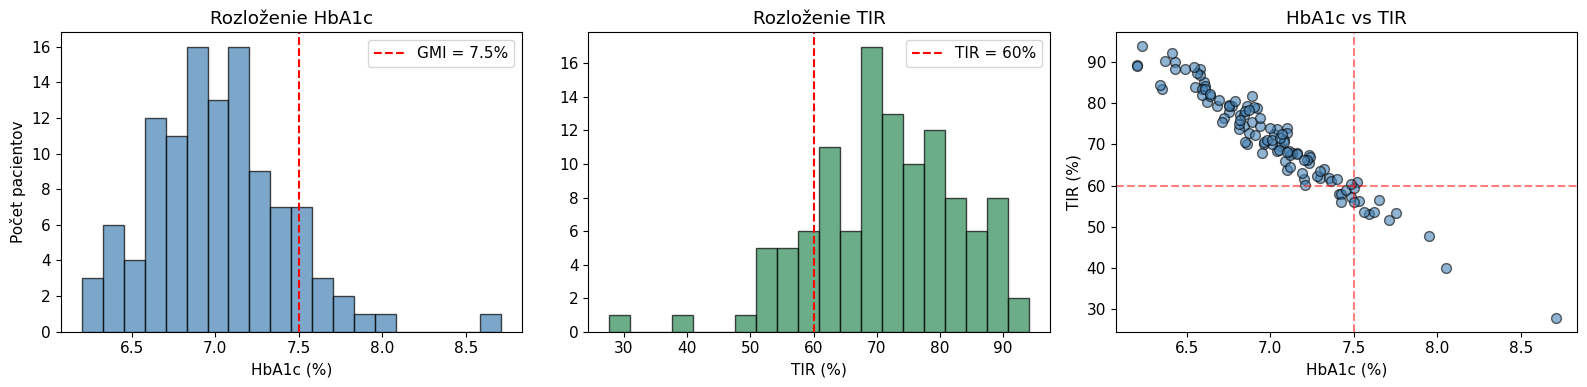

In [12]:
# Rozdelenie Hba1c a TIR
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(patient_metrics['hba1c'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(7.5, color='red', linestyle='--', label='GMI = 7.5%')
axes[0].set_xlabel('HbA1c (%)')
axes[0].set_ylabel('Počet pacientov')
axes[0].set_title('Rozloženie HbA1c')
axes[0].legend()

axes[1].hist(patient_metrics['tir_pct'], bins=20, edgecolor='black', alpha=0.7, color='seagreen')
axes[1].axvline(60, color='red', linestyle='--', label='TIR = 60%')
axes[1].set_xlabel('TIR (%)')
axes[1].set_title('Rozloženie TIR')
axes[1].legend()

axes[2].scatter(patient_metrics['hba1c'], patient_metrics['tir_pct'], 
                alpha=0.6, c='steelblue', edgecolors='black', s=50)
axes[2].axhline(60, color='red', linestyle='--', alpha=0.5)
axes[2].axvline(7.5, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('HbA1c (%)')
axes[2].set_ylabel('TIR (%)')
axes[2].set_title('HbA1c vs TIR')

plt.tight_layout()
plt.savefig(OUT_IMG + 'patient_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Výber pacienta

Vyberieme pacienta, ktorý spĺňa naše kritériá:
- **GMI > 7.5%** (vyššia glykémia → podľa paperu väčšia šanca na viditeľný efekt intervencií)
- **> 50 000 záznamov** (dostatočná dĺžka radu na analýzu)
- **TIR < 60%** (pod cieľom pre dobrú kompenzáciu)

In [13]:
# Filtrovanie kandidátov
candidates = patient_metrics[
    (patient_metrics['hba1c'] > 7.5) &
    (patient_metrics['n_records'] > 50000) &
    (patient_metrics['tir_pct'] < 60)
]

candidates

,n_records,days,mean_mmol,var_koef,hba1c,tir_pct,tbr_pct,tar_pct,date_start,date_end
PtID,,,,,,,,,,
19,53023,188,10.22,43.9,7.71,51.5,2.6,45.9,2018-05-14 06:13:09,2018-11-18 11:08:21
28,52668,188,10.32,34.8,7.75,53.4,0.7,45.9,2017-07-31 14:52:40,2018-02-04 16:08:05
41,51127,181,9.80,39.4,7.53,56.3,2.4,41.3,2017-10-19 18:41:30,2018-04-19 15:42:23
91,52213,183,12.54,31.7,8.71,27.7,1.6,70.7,2018-06-17 04:57:02,2018-12-17 21:22:48
95,51918,185,10.09,39.8,7.65,56.5,1.5,42.0,2018-01-15 13:02:00,2018-07-19 23:50:13
138,51565,183,10.01,29.8,7.62,53.5,0.5,46.0,2018-06-05 18:09:07,2018-12-05 23:57:01


In [14]:
SELECTED_PATIENT_ID = 28

## 4. Extrakcia a agregácia dát zvoleného pacienta

Postup:
1. Extrahovať záznamy zvoleného pacienta
2. Agregovať na **hodinové priemery** (frequency = 24 za deň)
3. Konvertovať mg/dL → mmol/l (delenie 18)

In [15]:
# Extrakcia
df_patient = df[df['PtID'] == SELECTED_PATIENT_ID].copy()
print(f'Počet záznamov pacienta s {SELECTED_PATIENT_ID}: {len(df_patient):,}')

Počet záznamov pacienta s 28: 52,668


In [16]:
# Zoradenie podľa času
df_patient = df_patient.sort_values('DataDtTm').reset_index(drop=True)

In [17]:
# Pridanie stĺpcov dátum + hodina
df_patient['date'] = df_patient['DataDtTm'].dt.date
df_patient['hour'] = df_patient['DataDtTm'].dt.hour
df_patient['date_hour'] = pd.to_datetime(
    df_patient['date'].astype(str) + ' ' + df_patient['hour'].astype(str) + ':00:00'
)

df_patient.head()

,PtID,RecID,DataDtTm,CGMValue,HighLowIndicator,DataDtTm_adjusted,date,hour,date_hour
0,28,77114,2017-07-31 14:52:40,144,0,NaN,2017-07-31,14,2017-07-31 14:00:00
1,28,77115,2017-07-31 14:57:40,147,0,NaN,2017-07-31,14,2017-07-31 14:00:00
2,28,77116,2017-07-31 15:02:40,152,0,NaN,2017-07-31,15,2017-07-31 15:00:00
3,28,77117,2017-07-31 15:07:40,142,0,NaN,2017-07-31,15,2017-07-31 15:00:00
4,28,77118,2017-07-31 15:12:40,142,0,NaN,2017-07-31,15,2017-07-31 15:00:00


In [18]:
# Detekcia nesprávnych hodnôt
# Fyziologicky reálne rozmedzie CGM: 40–400 mg/dL

print(f'\nRozdelenie CGMValue:')
print(df_patient['CGMValue'].describe())

# Detekcia problémových hodnôt
zeros = df_patient['CGMValue'] == 0
too_low = (df_patient['CGMValue'] > 0) & (df_patient['CGMValue'] < 40)
too_high = df_patient['CGMValue'] > 400

print(f'\n--- Nesprávne hodnoty ---')
print(f'  CGM = 0 (chyba senzora):     {zeros.sum()}')
print(f'  CGM < 40 (pod rozsahom):      {too_low.sum()}')
print(f'  CGM > 400 (nad rozsahom):     {too_high.sum()}')



Rozdelenie CGMValue:
count    52668.000000
mean       185.783835
std         64.717310
min          0.000000
25%        137.000000
50%        173.000000
75%        228.000000
max        400.000000
Name: CGMValue, dtype: float64

--- Nesprávne hodnoty ---
  CGM = 0 (chyba senzora):     243
  CGM < 40 (pod rozsahom):      0
  CGM > 400 (nad rozsahom):     0


In [19]:
# Nahradenie nesprávnych hodnôt za NaN
df_patient.loc[zeros | too_low | too_high, 'CGMValue'] = np.nan

In [20]:
# Agregácia na hodinové priemery
data_agg = df_patient.groupby('date_hour').agg(
    CGM_mgdl=('CGMValue', 'mean'),
    n_readings=('CGMValue', 'count')
).reset_index()

In [21]:
# Konverzia na mmol/l
data_agg['CGM_mmol'] = round(data_agg['CGM_mgdl'] / 18, 2)
data_agg.head(10)

,date_hour,CGM_mgdl,n_readings,CGM_mmol
0,2017-07-31 14:00:00,145.500000,2,8.08
1,2017-07-31 15:00:00,129.416667,12,7.19
2,2017-07-31 16:00:00,91.923077,13,5.11
3,2017-07-31 17:00:00,122.666667,12,6.81
4,2017-07-31 18:00:00,137.083333,12,7.62
5,2017-07-31 19:00:00,160.166667,12,8.90
6,2017-07-31 20:00:00,182.583333,12,10.14
7,2017-07-31 21:00:00,184.750000,12,10.26
8,2017-07-31 22:00:00,210.250000,12,11.68
9,2017-07-31 23:00:00,181.500000,12,10.08


In [22]:
print(f'Počet hodinových pozorovaní: {len(data_agg)}')
print(f'Obdobie: {data_agg["date_hour"].min()} — {data_agg["date_hour"].max()}')

Počet hodinových pozorovaní: 4383
Obdobie: 2017-07-31 14:00:00 — 2018-02-04 16:00:00


### Intervencie

In [23]:
rand = pd.read_csv('data/RandomizationCTV_a.txt', sep='|', encoding='utf-16')
print(rand.columns.tolist())
print(rand[rand['PtID'] == SELECTED_PATIENT_ID])

['ParentLoginVisitID', 'PtID', 'RecID', 'ProceduresComplete']
    ParentLoginVisitID  PtID  RecID ProceduresComplete
98                 208    28     25                Yes


In [24]:
run_in = pd.read_csv('data/RunInReview_a.txt', sep='|', encoding='utf-16')
print(run_in.columns.tolist())
print(run_in[run_in['PtID'] == SELECTED_PATIENT_ID])

['ParentLoginVisitID', 'PtID', 'RecID', 'CGMUsed11Days', 'PumpUsedDaily', 'PumpUsedDailyExplan', 'NeedMoreRunIn', 'NeedMoreRunInCGM', 'NeedMoreRunInPump', 'PumpSettingsChanged', 'SkinReaction', 'SkinReactionRedness', 'SkinReactionSwelling', 'SkinReactionPain', 'SkinReactionBruising']
    ParentLoginVisitID  PtID  RecID CGMUsed11Days PumpUsedDaily  \
64                 203    28     23           Yes            No   

   PumpUsedDailyExplan NeedMoreRunIn  NeedMoreRunInCGM  NeedMoreRunInPump  \
64        PersonalPump            No               NaN                NaN   

   PumpSettingsChanged SkinReaction  SkinReactionRedness  \
64                  No           No                  NaN   

    SkinReactionSwelling  SkinReactionPain  SkinReactionBruising  
64                   NaN               NaN                   NaN  


In [25]:
visits = pd.read_csv('data/VisitInfo_a.txt', sep='|', encoding='utf-16')
print(visits.columns.tolist())
print(visits[visits['PtID'] == SELECTED_PATIENT_ID])

['ParentLoginVisitID', 'PtID', 'RecID', 'Visit', 'VisitDt', 'OutOfWin', 'OutOfWinReason', 'VisitMiss', 'VisitMissReason']
      ParentLoginVisitID  PtID  RecID                Visit  \
63                    64    28     64            Screening   
64                    65    28     65    Run-in Initiation   
202                  203    28    203        Run-in Review   
207                  208    28    208        Randomization   
219                  220    28    220             Training   
354                  355    28    355          1-Week Call   
465                  466    28    466               2-Week   
607                  608    28    608  Unscheduled Contact   
779                  781    28    781          4-Week Call   
1100                1102    28   1102               6-Week   
1531                1535    28   1535          9-Week Call   
1701                1706    28   1706  Unscheduled Contact   
1797                1802    28   1802              13-Week   
2207      

Randomization 2017-07-31 T02

2-Week 2017-08-14 T2

13-Week 2017-10-23 T13

In [27]:
roster = pd.read_csv('data/PtRoster_a.txt', sep='|', encoding='utf-16')
print(roster.columns.tolist())
print(roster[roster['PtID'] == 28])

['PtID', 'EnrollDt', 'RandDt', 'trtGroup', 'PtStatus', 'SiteID']
    PtID             EnrollDt                         RandDt trtGroup  \
99    28  2017-07-17 00:00:00  2017-07-31 11:51:17.983000000      CLC   

     PtStatus  SiteID  
99  Completed       3  


In [32]:
# T0, T2, T13 z VisitInfo
visits = pd.read_csv('data/VisitInfo_a.txt', sep='|', encoding='utf-16')
visits['VisitDt'] = pd.to_datetime(visits['VisitDt'])
pt_visits = visits[visits['PtID'] == 28].set_index('Visit')['VisitDt']

t0  = pt_visits['Randomization']   # 2017-07-31
t2  = pt_visits['2-Week']          # 2017-08-14
t13 = pt_visits['13-Week']         # 2017-10-23

print(f'T0:  {t0.date()}')
print(f'T2:  {t2.date()}')
print(f'T13: {t13.date()}')

T0:  2017-07-31
T2:  2017-08-14
T13: 2017-10-23


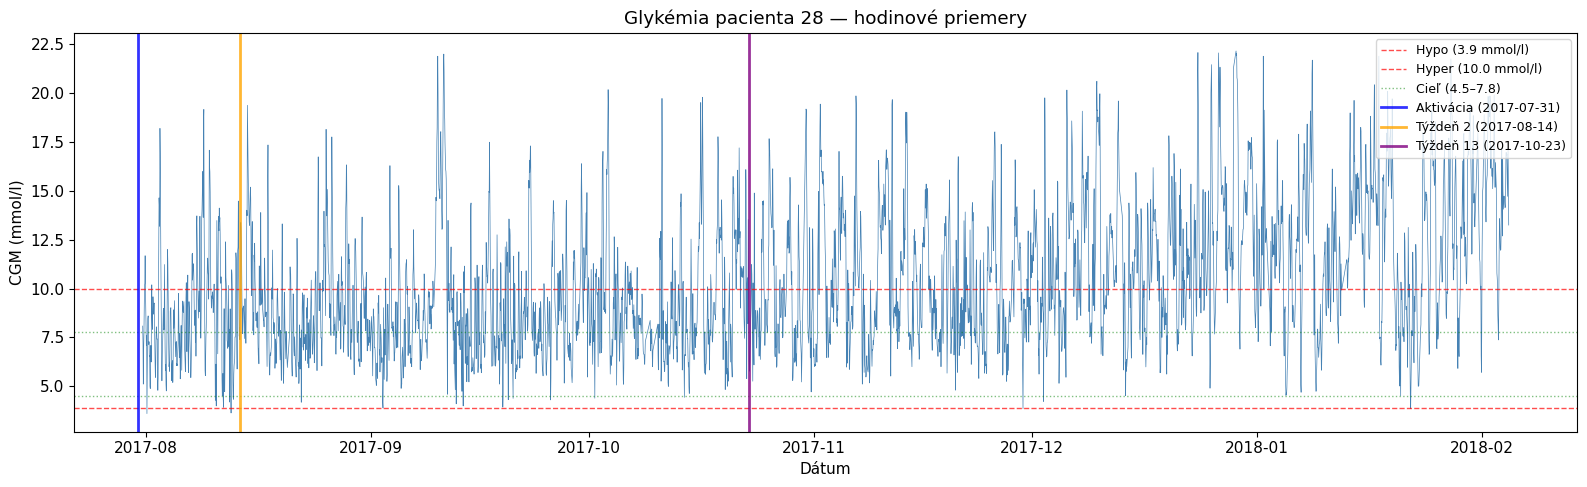

In [43]:
# Vizualizácia — celý hodinový časový rad
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(data_agg['date_hour'], data_agg['CGM_mmol'], linewidth=0.5, color='steelblue')

# Referenčné hranice
ax.axhline(3.9, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Hypo (3.9 mmol/l)')
ax.axhline(10.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Hyper (10.0 mmol/l)')
ax.axhline(4.5, color='green', linestyle=':', linewidth=1, alpha=0.5, label='Cieľ (4.5–7.8)')
ax.axhline(7.8, color='green', linestyle=':', linewidth=1, alpha=0.5)


ax.axvline(t0, color='blue', linestyle='-', linewidth=2, alpha=0.8, label=f'Aktivácia ({t0.strftime("%Y-%m-%d")})')
ax.axvline(t2, color='orange', linestyle='-', linewidth=2, alpha=0.8, label=f'Týždeň 2 ({t2.strftime("%Y-%m-%d")})')
ax.axvline(t13, color='purple', linestyle='-', linewidth=2, alpha=0.8, label=f'Týždeň 13 ({t13.strftime("%Y-%m-%d")})')

ax.set_xlabel('Dátum')
ax.set_ylabel('CGM (mmol/l)')
ax.set_title(f'Glykémia pacienta {SELECTED_PATIENT_ID} — hodinové priemery')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_IMG + 'selected_patient_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Kontrola chýbajúcich hodín

Overíme, či v hodinovom rade nie sú výrazné medzery (chýbajúce hodiny).

In [35]:
# Kontrola spojitosti hodinového radu
full_range = pd.date_range(start=data_agg['date_hour'].min(), 
                           end=data_agg['date_hour'].max(), freq='h')
missing_hours = full_range.difference(data_agg['date_hour'])

print(f'Očakávaný počet hodín: {len(full_range)}')
print(f'Skutočný počet hodín:  {len(data_agg)}')
print(f'Chýbajúcich hodín:     {len(missing_hours)}')
print(f'% chýbajúcich:         {len(missing_hours)/len(full_range)*100:.1f}%')

if len(missing_hours) > 0:
    print(f'\nPríklady chýbajúcich hodín (prvých 10):')
    for h in missing_hours[:10]:
        print(f'  {h}')

Očakávaný počet hodín: 4515
Skutočný počet hodín:  4383
Chýbajúcich hodín:     132
% chýbajúcich:         2.9%

Príklady chýbajúcich hodín (prvých 10):
  2017-08-10 13:00:00
  2017-08-20 13:00:00
  2017-08-20 14:00:00
  2017-08-20 15:00:00
  2017-08-20 16:00:00
  2017-08-20 17:00:00
  2017-08-20 18:00:00
  2017-08-20 19:00:00
  2017-08-30 17:00:00
  2017-09-09 17:00:00


In [36]:
# Dĺžky súvislých výpadkov
gaps = []
gap_start = None
for h in full_range:
    if h in missing_hours:
        if gap_start is None:
            gap_start = h
    else:
        if gap_start is not None:
            gap_len = int((h - gap_start).total_seconds() / 3600)
            gaps.append({'start': gap_start, 'hours': gap_len})
            gap_start = None

gaps_df = pd.DataFrame(gaps)
print(f'Počet súvislých výpadkov: {len(gaps_df)}')
print(gaps_df['hours'].describe())

Počet súvislých výpadkov: 26
count    26.000000
mean      5.076923
std       5.074825
min       1.000000
25%       1.000000
50%       2.500000
75%       7.750000
max      16.000000
Name: hours, dtype: float64


In [37]:
gaps_df.sort_values('hours', ascending=False)

,start,hours
22,2018-01-12 17:00:00,16
6,2017-10-08 20:00:00,15
8,2017-10-09 21:00:00,15
10,2017-10-30 08:00:00,13
21,2018-01-02 08:00:00,11
24,2018-01-31 01:00:00,9
18,2017-12-13 03:00:00,8
1,2017-08-20 13:00:00,7
5,2017-09-29 16:00:00,6
23,2018-01-23 08:00:00,5


In [38]:
# Doplnenie chýbajúcich hodín interpoláciou (ak existujú)
if len(missing_hours) > 0:
    data_agg = data_agg.set_index('date_hour').reindex(full_range).rename_axis('date_hour')
    # Lineárna interpolácia pre chýbajúce hodnoty
    data_agg['CGM_mmol'] = data_agg['CGM_mmol'].interpolate(method='linear')
    data_agg['CGM_mgdl'] = data_agg['CGM_mgdl'].interpolate(method='linear')
    data_agg = data_agg.reset_index()
    print(f'Doplnené interpoláciou. Počet hodín: {len(data_agg)}')
else:
    print('Žiadne chýbajúce hodiny — rad je kompletný.')

Doplnené interpoláciou. Počet hodín: 4515


## 6. Uloženie dát

Uložíme:
1. `data_patient_selected.csv` — hodinový časový rad (vstup pre 2. notebook)
2. `patient_info.txt` — metadata o pacientovi
3. `patient_metrics_all.csv` — metriky všetkých pacientov (pre prílohu)

In [39]:
# 1. Hodinový časový rad
output_cols = ['date_hour', 'CGM_mmol', 'CGM_mgdl']
data_agg[output_cols].to_csv(OUT_DATA + 'data_patient_selected.csv', index=False)
print(f'Uložené: data_patient_selected.csv ({len(data_agg)} riadkov)')

# 2. Metadata
info = candidates.loc[SELECTED_PATIENT_ID]
with open(OUT_DATA + 'patient_info.txt', 'w', encoding='utf-8') as f:
    f.write(f'patient_id={SELECTED_PATIENT_ID}\n')
    f.write(f'date_start={data_agg["date_hour"].min()}\n')
    f.write(f'date_end={data_agg["date_hour"].max()}\n')
    f.write(f't2={t2}\n')
    f.write(f't13={t13}\n')
    f.write(f'n_hourly={len(data_agg)}\n')
    f.write(f'mean_mmol={info["mean_mmol"]}\n')
    f.write(f'hba1c={info["hba1c"]}\n')
    f.write(f'tir_pct={info["tir_pct"]}\n')
print('Uložené: patient_info.txt')

# 3. Metriky všetkých pacientov
patient_metrics.to_csv(OUT_DATA + 'patient_metrics_all.csv')
print('Uložené: patient_metrics_all.csv')


Uložené: data_patient_selected.csv (4515 riadkov)
Uložené: patient_info.txt
Uložené: patient_metrics_all.csv
